In [3]:
import sys
import pandas as pd
sys.path.append('../') 

from src.data_loader import TimeSeriesDataLoader

loader = TimeSeriesDataLoader()

file_path = '../data/raw/Internal Submission Hourly 2024.csv' 
df = loader.load_and_clean(file_path)

feature_cols = [
    'Carbon intensity gCO₂eq/kWh (direct)', 
    'Carbon-free energy percentage (CFE%)', 
    'Renewable energy percentage (RE%)'
]

train_df, test_df = loader.split_and_scale(df, feature_cols=feature_cols, train_ratio=0.8)

look_back = 24       # Menggunakan histori 24 jam ke belakang
forecast_horizon = 1 # Memprediksi 1 jam ke depan

print("\nCreating sliding windows...")
X_train, y_train = loader.create_sliding_window(train_df, look_back, forecast_horizon)
X_test, y_test = loader.create_sliding_window(test_df, look_back, forecast_horizon)

#(Sanity Check)
print("\n--- Hasil Dimensi Array ---")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Loading data from ../data/raw/Internal Submission Hourly 2024.csv...
Data cleaned. Total baris: 8784
Splitting and Scaling data...

Creating sliding windows...

--- Hasil Dimensi Array ---
X_train shape: (7003, 24, 3)
y_train shape: (7003, 1)
X_test shape: (1733, 24, 3)
y_test shape: (1733, 1)


In [4]:
X_train_uni = X_train[:, :, 0:1]
X_test_uni = X_test[:, :, 0:1]

print("Shape Univariate Train:", X_train_uni.shape)
print("Shape Univariate Test:", X_test_uni.shape)

Shape Univariate Train: (7003, 24, 1)
Shape Univariate Test: (1733, 24, 1)


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model_uni = Sequential([
    LSTM(units=64, return_sequences=False, input_shape=(look_back, 1)),
    Dropout(0.2),
    # Output Layer (1 karena One-step Ahead)
    Dense(units=1)
])
model_uni.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

model_uni.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('../saved_models/dl_weights/univariate_lstm_best.keras', save_best_only=True)
]

print("\nMemulai Training Model Univariate LSTM...")
history_uni = model_uni.fit(
    X_train_uni, y_train,
    validation_data=(X_test_uni, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)


Memulai Training Model Univariate LSTM...
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0172 - mae: 0.0991 - val_loss: 0.0113 - val_mae: 0.0869
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0102 - mae: 0.0801 - val_loss: 0.0084 - val_mae: 0.0727
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0083 - mae: 0.0720 - val_loss: 0.0063 - val_mae: 0.0623
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0071 - mae: 0.0665 - val_loss: 0.0051 - val_mae: 0.0562
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0061 - mae: 0.0613 - val_loss: 0.0046 - val_mae: 0.0534
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0057 - mae: 0.0595 - val_loss: 0.0042 - val_mae: 0.0507
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0052 - mae: 0.0566 - val_loss: 0.0038 - val_mae: 0.0476
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0049 - mae: 0.0545 - val_loss: 0.0036 - val_mae: 0.0462
Epoch 9/50
21

melakukan prediksi...
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- Hasil Evaluasi (Skala gCO_2eq/kWh) ---
MAE  : 2.52
RMSE : 3.32
MAPE : 0.44%


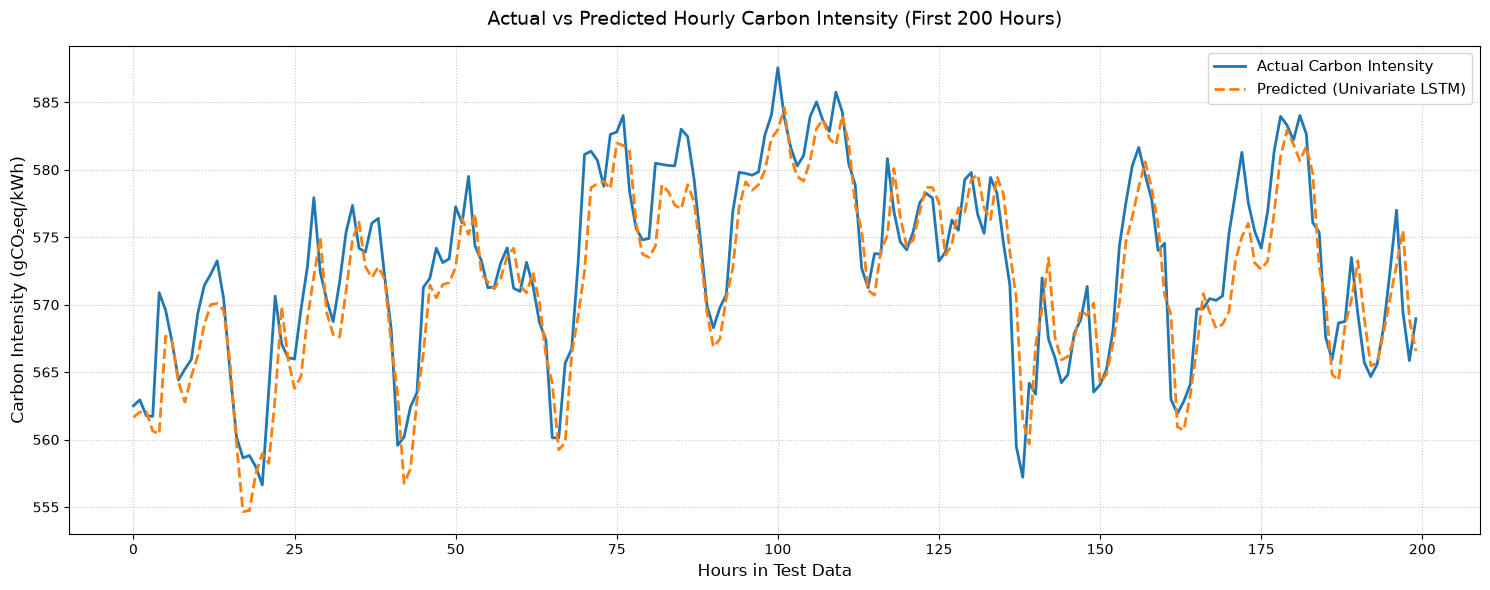

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("melakukan prediksi...")
y_pred_scaled = model_uni.predict(X_test_uni)

y_test_asli = loader.target_scaler.inverse_transform(y_test)
y_pred_asli = loader.target_scaler.inverse_transform(y_pred_scaled)

# Hitung Metrik Evaluasi
mae = mean_absolute_error(y_test_asli, y_pred_asli)
rmse = np.sqrt(mean_squared_error(y_test_asli, y_pred_asli))
mape = np.mean(np.abs((y_test_asli - y_pred_asli) / y_test_asli)) * 100

print("\n--- Hasil Evaluasi (Skala gCO_2eq/kWh) ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Visualisasi (Plotting)
# plot 200 jam pertama agar fluktuasinya terlihat jelas
plot_hours = 200

plt.figure(figsize=(15, 6))
plt.plot(y_test_asli[:plot_hours], label='Actual Carbon Intensity', color='#1f77b4', linewidth=2)
plt.plot(y_pred_asli[:plot_hours], label='Predicted (Univariate LSTM)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title('Actual vs Predicted Hourly Carbon Intensity (First 200 Hours)', fontsize=14, pad=15)
plt.xlabel('Hours in Test Data', fontsize=12)
plt.ylabel('Carbon Intensity (gCO₂eq/kWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Merapikan layout
plt.tight_layout()
plt.show()

In [7]:
num_features = X_train.shape[2]

model_multi = Sequential([
    LSTM(units=64, return_sequences=False, input_shape=(look_back, num_features)),
    Dropout(0.2),
    Dense(units=1)
])

model_multi.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

model_multi.summary()

callbacks_multi = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('../saved_models/dl_weights/multivariate_lstm_best.keras', save_best_only=True)
]

print("\nMemulai Training Model Multivariate LSTM...")
history_multi = model_multi.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_multi,
    verbose=1
)

/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,473 (68.25 KB)

 Trainable params: 17,473 (68.25 KB)

 Non-trainable params: 0 (0.00 B)


Memulai Training Model Multivariate LSTM...
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0213 - mae: 0.1084 - val_loss: 0.0105 - val_mae: 0.0827
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0100 - mae: 0.0796 - val_loss: 0.0072 - val_mae: 0.0669
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0074 - mae: 0.0678 - val_loss: 0.0053 - val_mae: 0.0573
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0063 - mae: 0.0624 - val_loss: 0.0050 - val_mae: 0.0552
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0054 - mae: 0.0578 - val_loss: 0.0042 - val_mae: 0.0505
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0052 - mae: 0.0563 - val_loss: 0.0037 - val_mae: 0.0471
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0049 - mae: 0.0543 - val_loss: 0.0035 - val_mae: 0.0461
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0046 - mae: 0.0525 - val_loss: 0.0048 - val_mae: 0.0538
Epoch 9/50


melakukan prediksi (Multivariate)...
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Perbandingan Hasil Evaluasi (Skala Asli) ---
| Metrik | Univariate | Multivariate |
|--------|------------|--------------|
| MAE    | 2.52       | 2.34         |
| RMSE   | 3.32       | 3.07         |
| MAPE   | 0.44%      | 0.41%        |


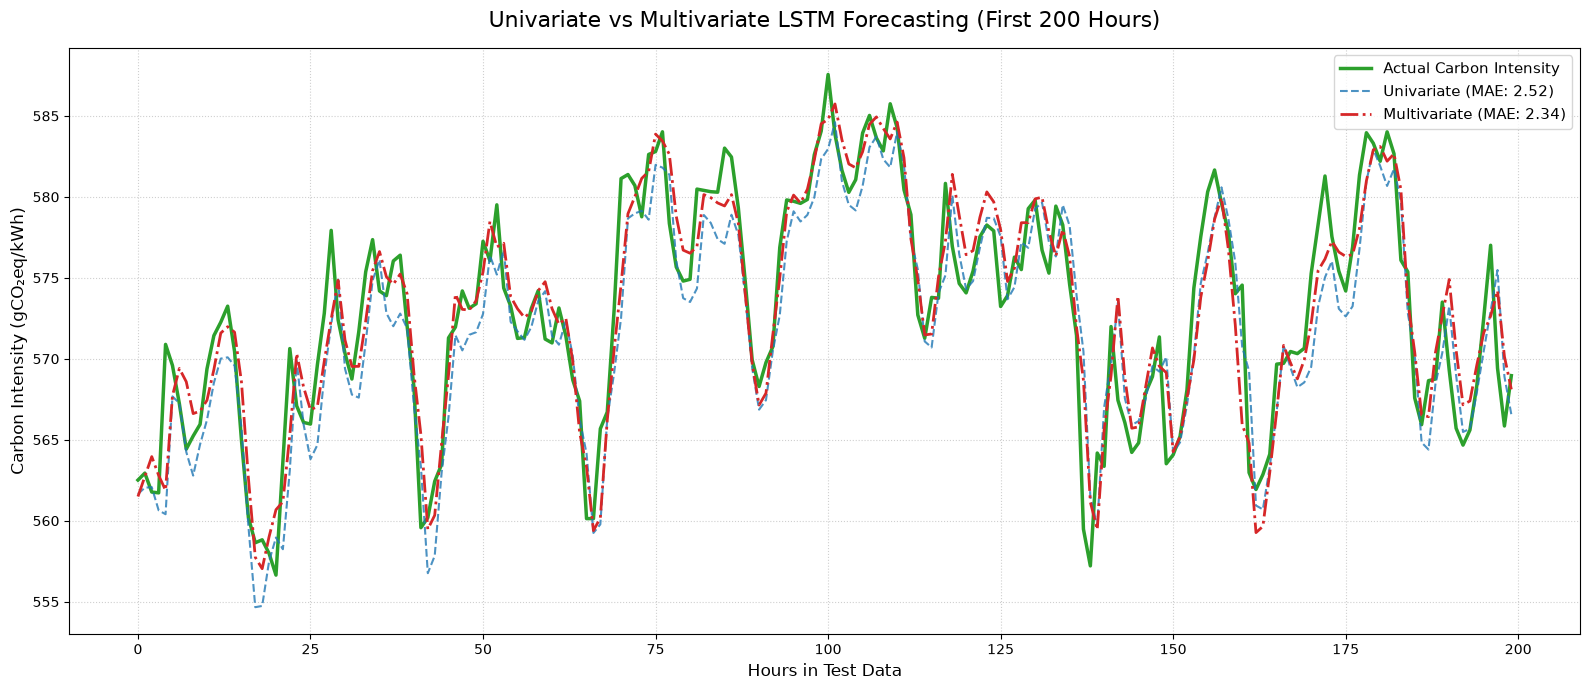

In [8]:
print("melakukan prediksi (Multivariate)...")
y_pred_multi_scaled = model_multi.predict(X_test)

y_pred_multi_asli = loader.target_scaler.inverse_transform(y_pred_multi_scaled)

mae_multi = mean_absolute_error(y_test_asli, y_pred_multi_asli)
rmse_multi = np.sqrt(mean_squared_error(y_test_asli, y_pred_multi_asli))
mape_multi = np.mean(np.abs((y_test_asli - y_pred_multi_asli) / y_test_asli)) * 100

print("\n--- Perbandingan Hasil Evaluasi (Skala Asli) ---")
print(f"| Metrik | Univariate | Multivariate |")
print(f"|--------|------------|--------------|")
print(f"| MAE    | {mae:.2f}       | {mae_multi:.2f}         |")
print(f"| RMSE   | {rmse:.2f}       | {rmse_multi:.2f}         |")
print(f"| MAPE   | {mape:.2f}%      | {mape_multi:.2f}%        |")

plot_hours = 200

plt.figure(figsize=(16, 7))
plt.plot(y_test_asli[:plot_hours], label='Actual Carbon Intensity', color='#2ca02c', linewidth=2.5) # Hijau
plt.plot(y_pred_asli[:plot_hours], label=f'Univariate (MAE: {mae:.2f})', color='#1f77b4', linestyle='--', alpha=0.8) # Biru
plt.plot(y_pred_multi_asli[:plot_hours], label=f'Multivariate (MAE: {mae_multi:.2f})', color='#d62728', linestyle='-.', linewidth=2) # Merah

plt.title('Univariate vs Multivariate LSTM Forecasting (First 200 Hours)', fontsize=16, pad=15)
plt.xlabel('Hours in Test Data', fontsize=12)
plt.ylabel('Carbon Intensity (gCO₂eq/kWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [9]:
from tensorflow.keras.layers import Bidirectional

model_bilstm = Sequential([
    Bidirectional(LSTM(units=64, return_sequences=False), input_shape=(look_back, num_features)),
    Dropout(0.2),
    Dense(units=1)
])

model_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)

model_bilstm.summary()

# Callbacks
callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('../saved_models/dl_weights/multivariate_bilstm_best.keras', save_best_only=True)
]

print("\nMemulai Training Model BiLSTM...")
history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks_bilstm,
    verbose=1
)

/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,945 (136.50 KB)

 Trainable params: 34,945 (136.50 KB)

 Non-trainable params: 0 (0.00 B)


Memulai Training Model BiLSTM...
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0184 - mae: 0.1023 - val_loss: 0.0086 - val_mae: 0.0757
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0079 - mae: 0.0704 - val_loss: 0.0062 - val_mae: 0.0624
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0054 - mae: 0.0575 - val_loss: 0.0040 - val_mae: 0.0493
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0047 - mae: 0.0534 - val_loss: 0.0037 - val_mae: 0.0468
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0045 - mae: 0.0521 - val_loss: 0.0035 - val_mae: 0.0462
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0042 - mae: 0.0506 - val_loss: 0.0039 - val_mae: 0.0482
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0041 - mae: 0.0498 - val_loss: 0.0032 - val_mae: 0.0439
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0040 - mae: 0.0496 - val_loss: 0.0032 - val_mae: 0.0441
Epoch 9/50
219/219 ━━━

Melakukan prediksi (Multivariate BiLSTM)...
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

--- EVALUASI 3 Model Deep Learning ---
| Metrik | Univariate | Multi LSTM | Multi BiLSTM |
|--------|------------|------------|--------------|
| MAE    | 2.52       | 2.34       | 2.38         |
| RMSE   | 3.32       | 3.07       | 3.13         |
| MAPE   | 0.44%      | 0.41%      | 0.42%        |


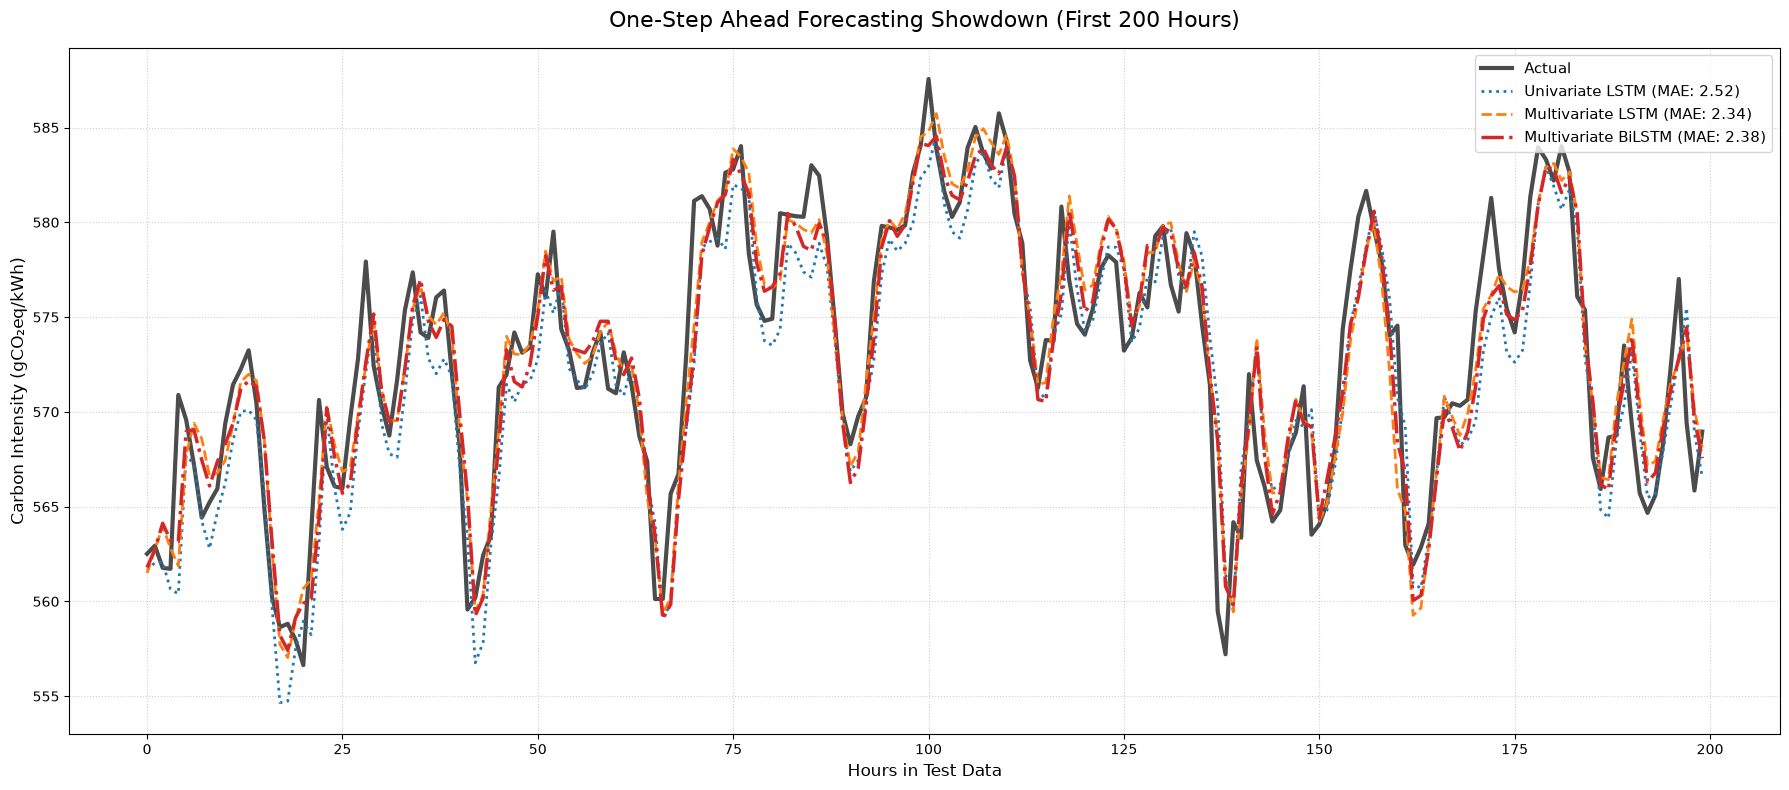

In [10]:
print("Melakukan prediksi (Multivariate BiLSTM)...")
y_pred_bilstm_scaled = model_bilstm.predict(X_test)

y_pred_bilstm_asli = loader.target_scaler.inverse_transform(y_pred_bilstm_scaled)

mae_bilstm = mean_absolute_error(y_test_asli, y_pred_bilstm_asli)
rmse_bilstm = np.sqrt(mean_squared_error(y_test_asli, y_pred_bilstm_asli))
mape_bilstm = np.mean(np.abs((y_test_asli - y_pred_bilstm_asli) / y_test_asli)) * 100

print("\n--- EVALUASI 3 Model Deep Learning ---")
print(f"| Metrik | Univariate | Multi LSTM | Multi BiLSTM |")
print(f"|--------|------------|------------|--------------|")
print(f"| MAE    | {mae:.2f}       | {mae_multi:.2f}       | {mae_bilstm:.2f}         |")
print(f"| RMSE   | {rmse:.2f}       | {rmse_multi:.2f}       | {rmse_bilstm:.2f}         |")
print(f"| MAPE   | {mape:.2f}%      | {mape_multi:.2f}%      | {mape_bilstm:.2f}%        |")

plot_hours = 200

plt.figure(figsize=(18, 8))
# Data Aktual
plt.plot(y_test_asli[:plot_hours], label='Actual', color='black', linewidth=3, alpha=0.7) 

# Prediksi Model
plt.plot(y_pred_asli[:plot_hours], label=f'Univariate LSTM (MAE: {mae:.2f})', color='#1f77b4', linestyle=':', linewidth=2)
plt.plot(y_pred_multi_asli[:plot_hours], label=f'Multivariate LSTM (MAE: {mae_multi:.2f})', color='#ff7f0e', linestyle='--', linewidth=2)
plt.plot(y_pred_bilstm_asli[:plot_hours], label=f'Multivariate BiLSTM (MAE: {mae_bilstm:.2f})', color='#d62728', linestyle='-.', linewidth=2.5)

plt.title('One-Step Ahead Forecasting Showdown (First 200 Hours)', fontsize=16, pad=15)
plt.xlabel('Hours in Test Data', fontsize=12)
plt.ylabel('Carbon Intensity (gCO₂eq/kWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [12]:
import optuna
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def objective(trial):
    units = trial.suggest_int('units', 32, 128, step=32)
    dropout_rate = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    model = Sequential([
        LSTM(units=units, return_sequences=False, input_shape=(24, 3)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=batch_size,
        verbose=0
    )
    
    # Ambil nilai MAE terbaik dari validation set
    val_mae = min(history.history['val_mae'])
    return val_mae

# menjalankan Optimasi
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("--- Hasil Optimasi Terbaik ---")
print(f"Trial terbaik: {study.best_trial.value}")
print(f"Params: {study.best_params}")

[I 2026-07-03 15:16:13,125] A new study created in memory with name: no-name-05e3e559-76c6-495f-b3cc-213c634c1c8a
[I 2026-07-03 15:16:33,024] Trial 0 finished with value: 0.0366324856877327 and parameters: {'units': 32, 'dropout': 0.11546087011778572, 'lr': 0.008400107672229644, 'batch_size': 16}. Best is trial 0 with value: 0.0366324856877327.
[I 2026-07-03 15:16:59,090] Trial 1 finished with value: 0.0381498821079731 and parameters: {'units': 64, 'dropout': 0.22952149107226982, 'lr': 0.004129953816187478, 'batch_size': 16}. Best is trial 0 with value: 0.0366324856877327.
[I 2026-07-03 15:17:18,556] Trial 2 finished with value: 0.04720660299062729 and parameters: {'units': 96, 'dropout': 0.25026187664746796, 'lr': 0.00037172215580037, 'batch_size': 64}. Best is trial 0 with value: 0.0366324856877327.
[I 2026-07-03 15:17:38,384] Trial 3 finished with value: 0.03665699064731598 and parameters: {'units': 32, 'dropout': 0.37906930052573606, 'lr': 0.008479814977825122, 'batch_size': 16}. B

--- Hasil Optimasi Terbaik ---
Trial terbaik: 0.03525609150528908
Params: {'units': 32, 'dropout': 0.10319849592643338, 'lr': 0.009709833086648797, 'batch_size': 16}


In [13]:
final_units = 32
final_dropout = 0.10319849592643338
final_lr = 0.009709833086648797
final_batch = 16

model_final = Sequential([
    LSTM(units=final_units, return_sequences=False, input_shape=(look_back, num_features)),
    Dropout(final_dropout),
    Dense(1)
])

model_final.compile(
    optimizer=Adam(learning_rate=final_lr),
    loss='mse',
    metrics=['mae']
)

# Training dengan parameter terbaik
history_final = model_final.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=final_batch,
    verbose=1
)

Epoch 1/50


/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0095 - mae: 0.0715 - val_loss: 0.0040 - val_mae: 0.0491
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0048 - mae: 0.0541 - val_loss: 0.0037 - val_mae: 0.0459
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0042 - mae: 0.0505 - val_loss: 0.0039 - val_mae: 0.0492
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0039 - mae: 0.0480 - val_loss: 0.0031 - val_mae: 0.0430
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0037 - mae: 0.0468 - val_loss: 0.0039 - val_mae: 0.0485
Epoch 6/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0452 - val_loss: 0.0032 - val_mae: 0.0433
Epoch 7/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0034 - mae: 0.0450 - val_loss: 0.0030 - val_mae: 0.0419
Epoch 8/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0033 - mae: 0.0445 - val_loss: 0.0030 - val_mae: 0.0422
Epoch 9/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0032 

In [15]:
y_pred_final_scaled = model_final.predict(X_test)

y_pred_final_asli = loader.target_scaler.inverse_transform(y_pred_final_scaled)

mae_final = mean_absolute_error(y_test_asli, y_pred_final_asli)
rmse_final = np.sqrt(mean_squared_error(y_test_asli, y_pred_final_asli))
mape_final = np.mean(np.abs((y_test_asli - y_pred_final_asli) / y_test_asli)) * 100

print(f"\n--- HASIL MODEL FINAL (Optimized) ---")
print(f"MAE  : {mae_final:.2f} gCO2eq/kWh")
print(f"RMSE : {rmse_final:.2f}")
print(f"MAPE : {mape_final:.4f}%")

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 911us/step

--- HASIL MODEL FINAL (Optimized) ---
MAE  : 1.99 gCO2eq/kWh
RMSE : 2.65
MAPE : 0.3516%


In [ ]:
def create_multistep_dataset(data, look_back=24, horizon=24):
    X, y = [], []
    for i in range(len(data) - look_back - horizon + 1):
        X.append(data[i:(i + look_back)])
        y.append(data[(i + look_back):(i + look_back + horizon), 0])
    return np.array(X), np.array(y)

# Gabungkan train & test yang sudah discale
scaled_full = pd.concat([train_df, test_df]).values

# Buat dataset multi-step (24 jam target)
X_ms, y_ms = create_multistep_dataset(scaled_full, look_back=look_back, horizon=24)
split_idx = int(len(X_ms) * 0.8)
X_train_ms, X_test_ms = X_ms[:split_idx], X_ms[split_idx:]
y_train_ms, y_test_ms = y_ms[:split_idx], y_ms[split_idx:]

print("X_ms shape:", X_ms.shape)
print("y_ms shape:", y_ms.shape)
print("X_train_ms shape:", X_train_ms.shape)
print("X_test_ms shape:", X_test_ms.shape)

# Arsitektur Multi-Output (24-step forecast)
model_multi_step = Sequential([
    LSTM(64, return_sequences=False, input_shape=(look_back, num_features)),
    Dropout(0.2),
    Dense(24)  # 24 output units untuk 24 jam ke depan
])

model_multi_step.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_multi_step.summary()

X_ms shape: (8737, 24, 3)
y_ms shape: (8737, 24)
X_train_ms shape: (6989, 24, 3)
X_test_ms shape: (1748, 24, 3)


/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_42"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_42 (LSTM)                  │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,968 (74.09 KB)

 Trainable params: 18,968 (74.09 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

callback_ms = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# Training Model Multi-Step
history_ms = model_multi_step.fit(
    X_train_ms, y_train_ms,
    validation_data=(X_test_ms, y_test_ms),
    epochs=50,
    batch_size=32,
    callbacks=[callback_ms],
    verbose=1
)

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0408 - mae: 0.1499 - val_loss: 0.0169 - val_mae: 0.1057
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0193 - mae: 0.1107 - val_loss: 0.0158 - val_mae: 0.1015
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0175 - mae: 0.1055 - val_loss: 0.0156 - val_mae: 0.1013
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0167 - mae: 0.1031 - val_loss: 0.0150 - val_mae: 0.0990
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0157 - mae: 0.1000 - val_loss: 0.0135 - val_mae: 0.0933
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0143 - mae: 0.0947 - val_loss: 0.0120 - val_mae: 0.0881
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0136 - mae: 0.0921 - val_loss: 0.0119 - val_mae: 0.0875
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0131 - mae: 0.0903 - val_loss: 0.0115 - val_mae: 0.0858
Epoch 9/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- HASIL FINAL: MULTI-STEP FORECASTING (24 Jam) ---
MAE  : 3.96 gCO2eq/kWh
RMSE : 5.11


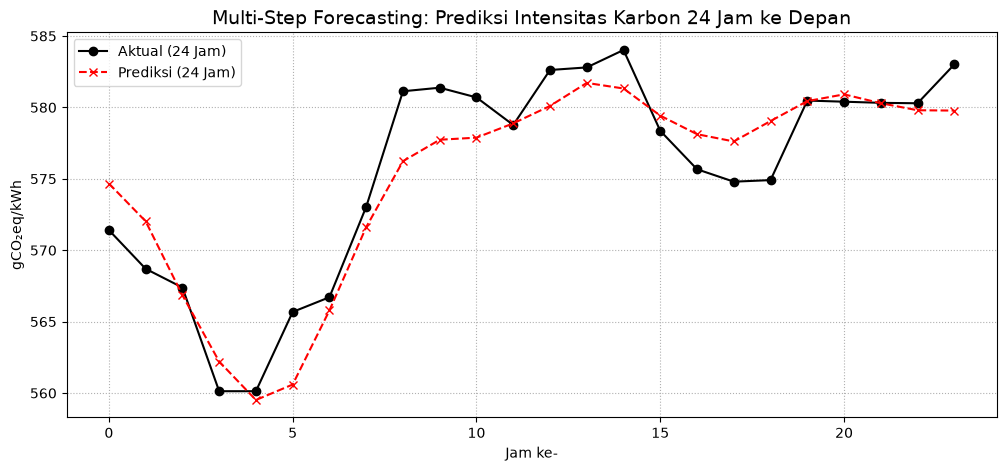

In [21]:
y_pred_ms_scaled = model_multi_step.predict(X_test_ms)

y_pred_ms_asli = loader.target_scaler.inverse_transform(y_pred_ms_scaled)
y_test_ms_asli = loader.target_scaler.inverse_transform(y_test_ms)

mae_ms = mean_absolute_error(y_test_ms_asli, y_pred_ms_asli)
rmse_ms = np.sqrt(mean_squared_error(y_test_ms_asli, y_pred_ms_asli))

print(f"\n--- HASIL FINAL: MULTI-STEP FORECASTING (24 Jam) ---")
print(f"MAE  : {mae_ms:.2f} gCO2eq/kWh")
print(f"RMSE : {rmse_ms:.2f}")

sample_idx = 100
plt.figure(figsize=(12, 5))
plt.plot(y_test_ms_asli[sample_idx], label='Aktual (24 Jam)', marker='o', color='black')
plt.plot(y_pred_ms_asli[sample_idx], label='Prediksi (24 Jam)', marker='x', color='red', linestyle='--')
plt.title(f'Multi-Step Forecasting: Prediksi Intensitas Karbon 24 Jam ke Depan', fontsize=14)
plt.xlabel('Jam ke-')
plt.ylabel('gCO₂eq/kWh')
plt.legend()
plt.grid(True, linestyle=':')
plt.show()